#### What are the most demanded skills for the top 3 most popular data roles?

##### Methodology

1. Clean-up skill column
2. Calculate skill count based on `job_title_short`
3. Calculate skill percentage
4. Plot final findings

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
import numpy as np
import ast
import seaborn as sns

# Loading Data set
dataset= load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [5]:
df_india = df[df['job_country'] == 'India']

In [6]:
df_india = df_india.explode('job_skills')

In [7]:
df_skills_count = df_india.groupby(['job_title_short','job_skills']).size()

df_skills_count = df_skills_count.reset_index(name='skill_count')

df_skills_count.sort_values(by='skill_count',ascending=False,inplace=True)


In [8]:
job_titles = df_skills_count['job_title_short'].unique().tolist()

job_titles=sorted(job_titles[:3])

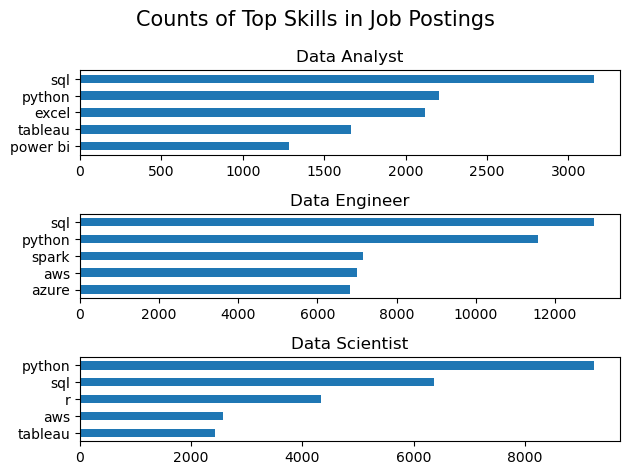

In [14]:
fig, ax = plt.subplots(len(job_titles),1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh',x='job_skills',y='skill_count',ax=ax[i],title=job_title) 
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

fig.suptitle('Counts of Top Skills in Job Postings', fontsize=15)

plt.tight_layout()

<div style='font-size:14px'> now we need to convert this skill count into percentage this will be done using this formuls. % of skill in a job postings=(skill count in job postings)/(total count of job postings)

In [17]:
df_jobs_count = df_india['job_title_short'].value_counts().reset_index(name='jobs_total')

<div style='font-size:14px'>now we will merge this data frame with skills count data frame

In [23]:
df_skills_perc = pd.merge(df_skills_count,df_jobs_count,how='left',on='job_title_short')

df_skills_perc['skill_perc']= 100 * df_skills_perc['skill_count']/df_skills_perc['jobs_total']

In [24]:
df_skills_perc

,job_title_short,job_skills,skill_count,jobs_total,skill_perc
0,Data Engineer,sql,12993,128144,10.139374
1,Data Engineer,python,11568,128144,9.027344
2,Data Scientist,python,9248,70549,13.108620
3,Data Engineer,spark,7157,128144,5.585123
4,Data Engineer,aws,6993,128144,5.457142
...,...,...,...,...,...
1684,Business Analyst,dart,1,6292,0.015893
1685,Business Analyst,datarobot,1,6292,0.015893
1686,Business Analyst,django,1,6292,0.015893
1687,Business Analyst,drupal,1,6292,0.015893


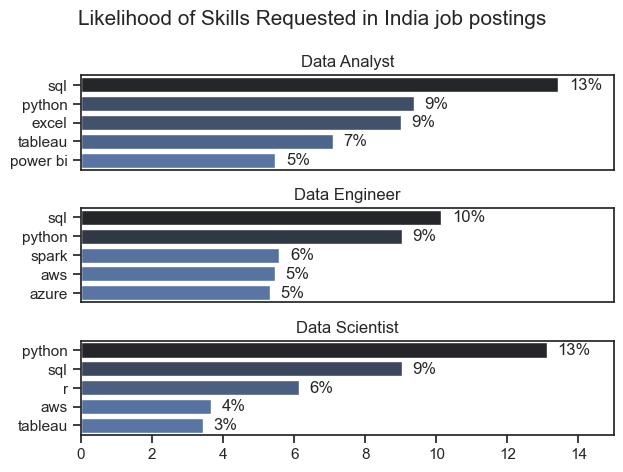

In [49]:
fig, ax = plt.subplots(len(job_titles),1)

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_perc',y='job_skills',ax=ax[i], hue='skill_count',palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 15)

    for n, v in enumerate(df_plot['skill_perc']):
        ax[i].text(v+0.3, n, f'{v:.0f}%', va='center') # .text(x position, y position, value, positioning of any axis)
        if i != len(job_titles) - 1:
            ax[i].set_xticks([])

fig.suptitle('Likelihood of Skills Requested in India job postings', fontsize=15)

plt.tight_layout()